In [8]:
from google.colab import drive
drive.mount('/content/drive')
#drive.mount('/content/drive', force_remount=True)

mat_path = '/content/drive/MyDrive/Colab Notebooks/SCR/NEDC_lite.mat'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
def run_scr_model(
    k_std_0,
    k_fst_0,
    k_slw_0,
    k_ads_0,
    k_des_0,
    k_nh3ox_0,
):
    import numpy as np
    import scipy.io as sio
    from scipy.integrate import solve_ivp

    # ---------- Lookup tables ----------
    NO_RATIO_BP = np.array(
        [131.3121, 161.1298, 224.8357, 265.8866, 322.246, 363.2026, 415.0273, 469.8143, 511.78],
        dtype=float,
    )
    NO_RATIO_TBL = np.array(
        [0.785714, 0.979592, 0.360825, 0.324138, 0.366906, 0.497227, 0.617626, 0.702214, 0.761749],
        dtype=float,
    )

    DENSITY_BP = np.array(
        [260, 280, 300, 350, 400, 450, 500, 600, 800, 1000, 1200, 1400],
        dtype=float,
    )
    DENSITY_TBL = np.array(
        [1.340, 1.245, 1.161, 0.995, 0.871, 0.774, 0.696, 0.580, 0.435, 0.348, 0.290, 0.249],
        dtype=float,
    )

    # ---------- Parameters ----------
    PARAMS = {
        "k_std_0": k_std_0,
        "k_fst_0": k_fst_0,
        "k_slw_0": k_slw_0,
        "k_ads_0": k_ads_0,
        "k_des_0": k_des_0,
        "k_nh3ox_0": k_nh3ox_0,
        "E1": 77300.0,
        "E2": 45200.0,
        "E3": 109000.0,
        "E4": -10200.0,
        "E5": 67500.0,
        "E6": 91100.0,
        "R": 8.314,
        "volume_m3": 0.000899,
        "ohm": 900.0,
        "switch_temp_scr_c": 190.0,
        "switch_no_ratio": 0.5,
    }

    def lookup(x, bp, table):
        return np.interp(x, bp, table, left=table[0], right=table[-1])

    def load_timeseries(mat_dict, name):
        obj = mat_dict[name][0, 0]
        t = np.asarray(obj["time"]).squeeze().astype(float)
        v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
        return t, v

    def deduplicate_time(t, *signals):
        _, first_idx = np.unique(t, return_index=True)
        first_idx = np.sort(first_idx)
        out = [t[first_idx]]
        for s in signals:
            out.append(s[first_idx])
        return tuple(out)

    def ppm_to_molm3(ppm):
        return ppm / 22.4 / 1000.0

    def molm3_to_ppm(c):
        return c * 1000.0 * 22.4

    def rate_constants(temp_c):
        T = np.asarray(temp_c, dtype=float) + 273.15
        k_std = PARAMS["k_std_0"] * np.exp(-PARAMS["E1"] / (PARAMS["R"] * T))
        k_fst = PARAMS["k_fst_0"] * np.exp(-PARAMS["E2"] / (PARAMS["R"] * T))
        k_slw = PARAMS["k_slw_0"] * np.exp(-PARAMS["E3"] / (PARAMS["R"] * T))
        k_ads = PARAMS["k_ads_0"] * np.exp(-PARAMS["E4"] / (PARAMS["R"] * T))
        k_des = PARAMS["k_des_0"] * np.exp(-PARAMS["E5"] / (PARAMS["R"] * T))
        k_nh3ox = PARAMS["k_nh3ox_0"] * np.exp(-PARAMS["E6"] / (PARAMS["R"] * T))
        return T, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox

    def gas_exchange_factor(exhaust_mg_s, temp_c):
        T, *_ = rate_constants(temp_c)
        rho = lookup(T, DENSITY_BP, DENSITY_TBL)
        exhaust_kg_s = np.asarray(exhaust_mg_s, dtype=float) * 1e-6
        q_m3_s = exhaust_kg_s / np.maximum(rho, 1e-12)
        F = q_m3_s / PARAMS["volume_m3"]
        return T, rho, F

    def feedforward_adblue(temp_doc_up_c, nox_f_ppm, exhaust_mg_s, temp_scr_up_c):
        no_ratio = lookup(temp_doc_up_c, NO_RATIO_BP, NO_RATIO_TBL)

        mw_no = 14.007 + 15.999
        mw_no2 = 14.007 + 15.999 * 2.0
        mw_nh3 = 14.007 + 1.008 * 3.0
        mw_exh = 29.47

        c_ratio = (no_ratio * mw_no + (1.0 - no_ratio) * mw_no2) / mw_exh
        nh3_vs_nox_ratio = mw_nh3 / (no_ratio * mw_no + (1.0 - no_ratio) * mw_no2)

        exhaust_kg_s = exhaust_mg_s * 1e-6
        nox_mass_like = c_ratio * nox_f_ppm * exhaust_kg_s
        base_nh3 = nh3_vs_nox_ratio * nox_mass_like
        extra_no2_comp = base_nh3 * (1.0 - 2.0 * no_ratio) * 0.333

        alpha_ratio = np.where(
            no_ratio >= PARAMS["switch_no_ratio"],
            base_nh3,
            base_nh3 + extra_no2_comp,
        )

        urea_mg_s = alpha_ratio * (60.0 / 34.0)
        adblue_mg_s = urea_mg_s * (100.0 / 32.4)
        adblue_mg_s = np.where(temp_scr_up_c >= PARAMS["switch_temp_scr_c"], adblue_mg_s, 0.0)

        return adblue_mg_s, no_ratio

    def adblue_to_nh3_in_molm3(adblue_mg_s, exhaust_mg_s):
        return (
            ((adblue_mg_s * (32.4 / 100.0) * (34.0 / 60.0)) / np.maximum(exhaust_mg_s, 1e-12))
            * 1e6
            * (28.8 / 17.0)
            / 1000.0
            / 22.4
        )

    # ---------- Load .mat ----------
    mat = sio.loadmat(mat_path)

    t, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
    _, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")
    _, Dosing = load_timeseries(mat, "Dosing")
    _, Temp = load_timeseries(mat, "Temp")
    _, ExhaustFlow = load_timeseries(mat, "ExhaustFlow")
    _, adblue_mg = load_timeseries(mat, "adblue_mg")
    _, O2 = load_timeseries(mat, "O2")
    _, Temp_DOC_up = load_timeseries(mat, "Temp_DOC_up")

    # use controller dosing exactly like your original code
    adblue_cmd, no_ratio = feedforward_adblue(Temp_DOC_up, F_NOx_sensor, ExhaustFlow, Temp)
    adblue_used = adblue_cmd

    NO_in_ppm = no_ratio * F_NOx_sensor
    NO2_in_ppm = (1.0 - no_ratio) * F_NOx_sensor

    NO_in = ppm_to_molm3(NO_in_ppm)
    NO2_in = ppm_to_molm3(NO2_in_ppm)
    NH3_in = adblue_to_nh3_in_molm3(adblue_used, ExhaustFlow)
    O2_in = O2 * 1e-2

    t_u, Temp_u, ExhaustFlow_u, O2_u, NO_in_u, NO2_in_u, NH3_in_u, R_NOx_u = deduplicate_time(
        t, Temp, ExhaustFlow, O2_in, NO_in, NO2_in, NH3_in, R_NOx_sensor
    )

    def interp_series(tt, arr):
        return float(np.interp(tt, t_u, arr, left=arr[0], right=arr[-1]))

    def rhs(tt, y):
        cno, cno2, theta, cnh3 = np.maximum(y, 0.0)

        temp_c = interp_series(tt, Temp_u)
        exh = interp_series(tt, ExhaustFlow_u)
        o2 = interp_series(tt, O2_u)
        no_in_val = interp_series(tt, NO_in_u)
        no2_in_val = interp_series(tt, NO2_in_u)
        nh3_in_val = interp_series(tt, NH3_in_u)

        _, _, F = gas_exchange_factor(exh, temp_c)
        _, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox = rate_constants(temp_c)

        Rads = k_ads * cnh3 * (1.0 - theta) * PARAMS["ohm"]
        Rdes = k_des * theta * PARAMS["ohm"]
        Roxi = k_nh3ox * o2 * theta * PARAMS["ohm"]
        Rstd = k_std * cno * o2 * theta * PARAMS["ohm"]
        Rfst = k_fst * cno * cno2 * theta * PARAMS["ohm"]
        Rslw = k_slw * cno2 * theta * PARAMS["ohm"]

        dcno = F * no_in_val - 4.0 * Rstd - 2.0 * Rfst - F * cno
        dcno2 = F * no2_in_val - 2.0 * Rfst - 3.0 * Rslw - F * cno2
        dtheta = (Rads - Rdes - 4.0 * Roxi - 4.0 * Rstd - 4.0 * Rfst - 4.0 * Rslw) / PARAMS["ohm"]
        dcnh3 = F * nh3_in_val - Rads + Rdes - 4.0 * Roxi - F * cnh3

        return np.array([dcno, dcno2, dtheta, dcnh3], dtype=float)

    sol = solve_ivp(
        rhs,
        (float(t_u[0]), float(t_u[-1])),
        y0=np.array([0.0, 0.0, 0.0, 0.0], dtype=float),
        t_eval=t_u,
        method="BDF",
        rtol=1e-5,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")

    cno_u, cno2_u, theta_u, cnh3_u = sol.y

    cno = np.interp(t, t_u, cno_u)
    cno2 = np.interp(t, t_u, cno2_u)
    cnh3 = np.interp(t, t_u, cnh3_u)

    NO_out_ppm = molm3_to_ppm(cno)
    NO2_out_ppm = molm3_to_ppm(cno2)
    NH3_out_ppm = molm3_to_ppm(cnh3)

    Model_NOx_ppm = NO_out_ppm + NO2_out_ppm
    Model_sensor_ppm = Model_NOx_ppm + NH3_out_ppm

    return t, Model_sensor_ppm

In [10]:
time_s, Model_sensor_ppm = run_scr_model(
    k_std_0=3.59e9,
    k_fst_0=8.80e9,
    k_slw_0=3.56e11,
    k_ads_0=4.32,
    k_des_0=4.83e4,
    k_nh3ox_0=6.99e5,
)

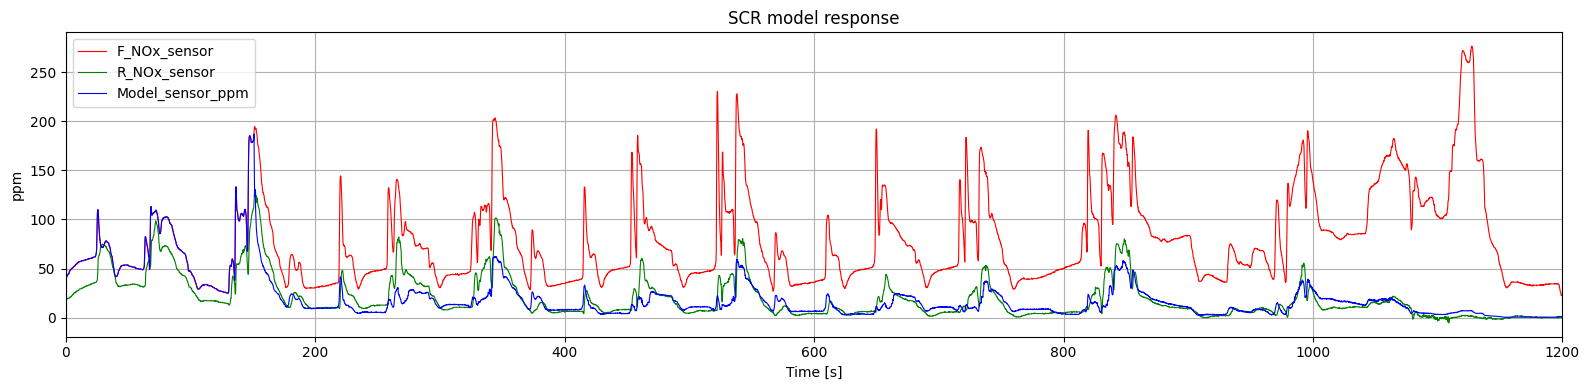

In [13]:
import matplotlib.pyplot as plt
import scipy.io as sio
import numpy as np

# Define load_timeseries function here so it's accessible
def load_timeseries(mat_dict, name):
    obj = mat_dict[name][0, 0]
    t = np.asarray(obj["time"]).squeeze().astype(float)
    v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
    return t, v

# ---- Load only the two measured signals for plotting ----
mat = sio.loadmat(mat_path)

t_f, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
t_r, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")

# ---- Plot ----
plt.figure(figsize=(16, 4))
plt.plot(t_f, F_NOx_sensor, label="F_NOx_sensor", color='red', linewidth=0.8)
plt.plot(t_r, R_NOx_sensor, label="R_NOx_sensor", color='green', linewidth=0.8)
plt.plot(time_s, Model_sensor_ppm, label="Model_sensor_ppm", color='blue', linewidth=0.8)

plt.xlim(0, 1200)   # optional
plt.xlabel("Time [s]")
plt.ylabel("ppm")
plt.title("SCR model response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()